# Evaluate spot separation models on a 5000-sample subset

This notebook evaluates trained two-output spot-separation models on
`data_10000_spots/augmented_spots_train.h5`.

It separates the evaluation into three parts:

- **Mask quality:** Dice and IoU are computed against `spot_masks` when present.
- **Intensity quality:** RMSE and Integrated Intensity Error are computed on the target spot masks.
- **Spot counter:** every target spot is assigned to an acceptance bin based on a combined Dice/RMSE recognition score.
- **Runtime:** evaluation time is tracked per model, per sample, and per spot.

The two model output channels are unordered, so predictions are aligned to the target channels before all metrics are computed.

In [1]:
from pathlib import Path
import json
import re
import time

import h5py
import hdf5plugin  # noqa: F401 - registers compressed HDF5 filters
import matplotlib.pyplot as plt
import numpy as np
try:
    import pandas as pd
except ImportError as exc:
    raise ImportError("This notebook needs pandas for result tables. Install it with: uv add pandas") from exc
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

from unet_model import UNet

/home/natalie.b/.conda/envs/spots/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Set `MODEL_PATHS` explicitly if your server checkpoints live somewhere else. The automatic search only looks below the project folder.

In [2]:
DATA_PATH = Path("data_100000_spots/augmented_spots_train.h5")

SUBSET_SIZE = 5000
RANDOM_SEED = 42
BATCH_SIZE = 32
NUM_WORKERS = 0

# Used only if spot_masks are missing, and for converting predicted intensities to binary masks.
TARGET_MASK_FALLBACK_THRESHOLD = 1e-4
PREDICTION_MASK_THRESHOLD = 0.5

# Spot-recognition score = DICE_WEIGHT * dice + RMSE_WEIGHT * intensity_score.
# intensity_score is 1 - normalized_rmse, clipped to [0, 1].
DICE_WEIGHT = 0.5
RMSE_WEIGHT = 0.5

AMP = torch.cuda.is_available()
BILINEAR = False  # must match the training flag used for the checkpoint

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE


device(type='cuda')

In [3]:
OUTPUT_DIR = Path("evaluation/0721-1027_newloss_twooutput")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# Option 1: fill this manually, e.g. [Path("server_models/final_model_a.pth"), ...]
MODEL_PATHS = [Path("checkpoints/final_20260721-102717_to_newloss_augmented_spots_train_e200_b10_lr0.0001_s1.pth")]
IS_32 = set()  # add checkpoint Paths here for base_features=32; all others use base_features=64

# Option 2: automatic local search if MODEL_PATHS is empty.
MODEL_SEARCH_ROOTS = [Path("checkpoints")]



## Inspect HDF5 structure and donor metadata

If the archive was produced by `augment_data/augmentation.ipynb` and then cropped by `augment_data/crop_384_to_128.ipynb`, donor information should still be available. The original augmentation writes `sample.attrs["donors"]` and root-level `provenance/source_donor_groups`; the crop notebook copies attributes and non-cropped groups.

In [4]:
def sample_group_names(h5_file):
    return sorted(
        name
        for name, obj in h5_file.items()
        if isinstance(obj, h5py.Group) and "image" in obj and "spot_images" in obj
    )


def inspect_h5_metadata(path):
    if not path.exists():
        raise FileNotFoundError(f"HDF5 file not found: {path.resolve()}")

    with h5py.File(path, "r") as f:
        names = sample_group_names(f)
        if not names:
            raise ValueError("No sample groups with image and spot_images were found.")

        first = f[names[0]]
        report = {
            "n_samples": len(names),
            "root_attrs": dict(f.attrs),
            "first_sample": names[0],
            "first_sample_attrs": dict(first.attrs),
            "datasets": {key: {"shape": value.shape, "dtype": str(value.dtype)} for key, value in first.items()},
            "has_spot_masks": "spot_masks" in first,
            "has_sample_donors_attr": "donors" in first.attrs,
            "has_root_provenance": "provenance" in f,
            "provenance_keys": list(f["provenance"].keys()) if "provenance" in f else [],
            "has_source_splits": "source_splits" in f,
        }
    return report


report = inspect_h5_metadata(DATA_PATH)
report

{'n_samples': 80000,
 'root_attrs': {'crop_policy': 'center crop only; no resizing or interpolation',
  'crop_size': np.int64(128),
  'cropped_patch_shape': '[128, 128]',
  'experiments': '["Al_big_grains_logtif", "Al_deformed_LoG_logtif", "Al_segvol", "Al_small_grains_logtif", "Cu_logtif", "IN718_twins_logtif", "Iron_deformed_logtif", "Iron_logtif", "Ti7Al_logtif"]',
  'fixed_patch_shape': '[384, 384]',
  'format': 'two_spot_intensity_separation',
  'friedel_split_policy': 'both members kept in same source split; otherwise ignored',
  'original_patch_shape': '[384, 384]',
  'overlap_range': '[0.1, 0.9]',
  'rotation_range_degrees': '[0.0, 360.0]',
  'sample_quotas': '{"Al_big_grains_logtif": 8889, "Al_deformed_LoG_logtif": 8889, "Al_segvol": 8889, "Al_small_grains_logtif": 8889, "Cu_logtif": 8889, "IN718_twins_logtif": 8889, "Iron_deformed_logtif": 8889, "Iron_logtif": 8889, "Ti7Al_logtif": 8888}',
  'seed': np.int64(7),
  'source_archive': '/VOL_D/natalie.b/data_100000_spots/augmente

In [5]:
def choose_subset_indices(n_samples, subset_size=SUBSET_SIZE, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    size = min(subset_size, n_samples)
    return np.sort(rng.choice(n_samples, size=size, replace=False))


with h5py.File(DATA_PATH, "r") as f:
    ALL_SAMPLE_NAMES = sample_group_names(f)

SUBSET_INDICES = choose_subset_indices(len(ALL_SAMPLE_NAMES))
SUBSET_NAMES = [ALL_SAMPLE_NAMES[i] for i in SUBSET_INDICES]
print(f"Using {len(SUBSET_NAMES)} random samples from {len(ALL_SAMPLE_NAMES)} total samples.")
print(SUBSET_NAMES[:5])

Using 5000 random samples from 80000 total samples.
['sample_000040', 'sample_000043', 'sample_000082', 'sample_000096', 'sample_000116']


## Dataset loader

The main target normalization uses `high = percentile(all finite image pixels, 99.9)` without subtracting a low percentile. A second positive-only normalization uses `high = percentile(positive image values, 99.9)` and is used for the recognition NRMSE/intensity score.


In [9]:
def normalize_image_and_targets(image, targets):
    image = image.astype(np.float32, copy=False)
    targets = targets.astype(np.float32, copy=False)
    finite_image = np.isfinite(image)
    if not finite_image.any():
        zeros_image = np.zeros_like(image, dtype=np.float32)
        zeros_targets = np.zeros_like(targets, dtype=np.float32)
        return zeros_image, zeros_targets, zeros_targets.copy(), np.float32(1.0)

    clean_image = np.where(finite_image, image, 0.0)
    clean_targets = np.where(np.isfinite(targets), targets, 0.0)
    np.maximum(clean_targets, 0.0, out=clean_targets)

    finite_values = clean_image[finite_image]
    high = float(np.percentile(finite_values, 99.9))
    if high <= 0:
        high = float(finite_values.max())
    if high <= 0:
        zeros_image = np.zeros_like(image, dtype=np.float32)
        zeros_targets = np.zeros_like(targets, dtype=np.float32)
        return zeros_image, zeros_targets, zeros_targets.copy(), np.float32(1.0)

    positive_values = clean_image[clean_image > 0]
    positive_high = float(np.percentile(positive_values, 99.9)) if positive_values.size else high
    if positive_high <= 0:
        positive_high = high

    normalized_targets = np.clip(clean_targets, 0.0, high) / high
    normalized_targets_positive = np.clip(clean_targets, 0.0, positive_high) / positive_high
    normalized_image = normalized_targets.sum(axis=0, dtype=np.float32)
    positive_scale = np.float32(high / positive_high)
    return (
        normalized_image.astype(np.float32, copy=False),
        normalized_targets.astype(np.float32, copy=False),
        normalized_targets_positive.astype(np.float32, copy=False),
        positive_scale,
    )



def sample_index_from_name(name):
    match = re.search(r"(\d+)$", name)
    return int(match.group(1)) if match else None


def decode_attr(value):
    if isinstance(value, bytes):
        return value.decode("utf-8")
    return value


def donor_keys_from_sample(h5_file, sample_name):
    group = h5_file[sample_name]
    if "donors" in group.attrs:
        donors = json.loads(decode_attr(group.attrs["donors"]))
        return [
            "|".join(str(donor.get(key, "?")) for key in ("experiment", "source_file", "donor_group", "source_row", "blob_id"))
            for donor in donors
        ]
    if "provenance" in h5_file and "source_donor_groups" in h5_file["provenance"]:
        sample_index = sample_index_from_name(sample_name)
        if sample_index is not None:
            provenance = h5_file["provenance"]
            donor_groups = provenance["source_donor_groups"][sample_index]
            rows = provenance["source_rows"][sample_index] if "source_rows" in provenance else ["?", "?"]
            blob_ids = provenance["source_blob_ids"][sample_index] if "source_blob_ids" in provenance else ["?", "?"]
            experiment = decode_attr(group.attrs.get("experiment", "?"))
            return [f"{experiment}|donor_group={int(d)}|row={int(r)}|blob={int(b)}" for d, r, b in zip(donor_groups, rows, blob_ids)]
    return []


class H5SubsetDataset(Dataset):
    def __init__(self, h5_path, sample_names, img_scale=1.0):
        self.h5_path = Path(h5_path)
        self.sample_names = list(sample_names)
        self.img_scale = img_scale

    def __len__(self):
        return len(self.sample_names)

    def __getitem__(self, idx):
        sample_name = self.sample_names[idx]
        with h5py.File(self.h5_path, "r") as f:
            group = f[sample_name]
            image = group["image"][()]
            targets = group["spot_images"][()]
            masks = group["spot_masks"][()] if "spot_masks" in group else None
            donor_keys = donor_keys_from_sample(f, sample_name)
            attrs = {key: decode_attr(value) for key, value in group.attrs.items() if key != "donors"}

        if image.ndim == 3:
            image = image.mean(axis=-1)
        if targets.ndim != 3 or targets.shape[0] != 2:
            raise ValueError(f"{sample_name}: expected spot_images shape (2, H, W), got {targets.shape}")

        image, targets, positive_targets, positive_scale = normalize_image_and_targets(image, targets)
        if masks is None:
            masks = targets > TARGET_MASK_FALLBACK_THRESHOLD
        else:
            masks = masks.astype(bool, copy=False)

        image_tensor = torch.from_numpy(image).unsqueeze(0)
        target_tensor = torch.from_numpy(targets)
        target_positive_tensor = torch.from_numpy(positive_targets)
        positive_scale_tensor = torch.tensor(positive_scale, dtype=torch.float32)
        mask_tensor = torch.from_numpy(masks.astype(bool, copy=False))

        if self.img_scale != 1.0:
            size = (
                max(1, int(image_tensor.shape[1] * self.img_scale)),
                max(1, int(image_tensor.shape[2] * self.img_scale)),
            )
            image_tensor = F.interpolate(image_tensor.unsqueeze(0), size=size, mode="bilinear", align_corners=False).squeeze(0)
            target_tensor = F.interpolate(target_tensor.unsqueeze(0), size=size, mode="bilinear", align_corners=False).squeeze(0)
            target_positive_tensor = F.interpolate(target_positive_tensor.unsqueeze(0), size=size, mode="bilinear", align_corners=False).squeeze(0)
            mask_tensor = F.interpolate(mask_tensor.float().unsqueeze(0), size=size, mode="nearest").squeeze(0).bool()

        return {
            "image": image_tensor,
            "target_intensity": target_tensor,
            "target_intensity_positive": target_positive_tensor,
            "positive_scale": positive_scale_tensor,
            "target_mask": mask_tensor,
            "sample_name": sample_name,
            "donor_keys": donor_keys,
            "attrs": attrs,
        }


def collate_batch(batch):
    return {
        "image": torch.stack([item["image"] for item in batch]),
        "target_intensity": torch.stack([item["target_intensity"] for item in batch]),
        "target_intensity_positive": torch.stack([item["target_intensity_positive"] for item in batch]),
        "positive_scale": torch.stack([item["positive_scale"] for item in batch]),
        "target_mask": torch.stack([item["target_mask"] for item in batch]),
        "sample_name": [item["sample_name"] for item in batch],
        "donor_keys": [item["donor_keys"] for item in batch],
        "attrs": [item["attrs"] for item in batch],
    }


dataset = H5SubsetDataset(DATA_PATH, SUBSET_NAMES)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_batch)


## Metrics

Dice and IoU are mask metrics. RMSE, Integrated Intensity Error, and soft intensity Dice are intensity metrics measured only inside the ground-truth spot masks.

Soft intensity Dice is useful as an additional overlap-style intensity metric: it rewards intensity mass that lands in the same foreground support as the target, but it should be read together with RMSE and Integrated Intensity Error because it is less directly interpretable in physical intensity units.

The **spot recognition score** combines mask overlap and intensity agreement:

`spot_recognition = 0.5 * Dice + 0.5 * max(0, 1 - positive_normalized_RMSE)`

The score is then binned into `<50%`, `50-70%`, `70-90%`, and `>90%`.

In [10]:
EPS = 1e-7
SPOT_BIN_ORDER = ["<50%", "50-70%", "70-90%", ">90%"]


def spot_intensity_prediction(logits):
    return F.softplus(logits)


def prediction_masks_from_intensity(prediction):
    return prediction > PREDICTION_MASK_THRESHOLD


def mask_dice_iou_from_masks(pred_mask, target_mask):
    intersection = (pred_mask & target_mask).sum(dim=(2, 3)).float()
    pred_area = pred_mask.sum(dim=(2, 3)).float()
    target_area = target_mask.sum(dim=(2, 3)).float()
    union = (pred_mask | target_mask).sum(dim=(2, 3)).float()
    dice = (2.0 * intersection + EPS) / (pred_area + target_area + EPS)
    iou = (intersection + EPS) / (union + EPS)
    return dice, iou


def foreground_rmse(prediction, target_intensity, target_mask):
    weights = target_mask.float()
    squared_error = (prediction - target_intensity).square() * weights
    pixel_count = weights.sum(dim=(2, 3)).clamp_min(1.0)
    rmse = torch.sqrt(squared_error.sum(dim=(2, 3)) / pixel_count)
    target_rms = torch.sqrt((target_intensity.square() * weights).sum(dim=(2, 3)) / pixel_count).clamp_min(EPS)
    nrmse = rmse / target_rms
    intensity_score = (1.0 - nrmse).clamp(0.0, 1.0)
    return rmse, nrmse, intensity_score


def soft_intensity_dice(prediction, target_intensity, target_mask):
    weights = target_mask.float()
    pred = prediction * weights
    target = target_intensity * weights
    numerator = 2.0 * (pred * target).sum(dim=(2, 3)) + EPS
    denominator = pred.square().sum(dim=(2, 3)) + target.square().sum(dim=(2, 3)) + EPS
    return numerator / denominator


def integrated_intensity_error(prediction, target_intensity, target_mask):
    weights = target_mask.float()
    pred_integral = (prediction * weights).sum(dim=(2, 3))
    target_integral = (target_intensity * weights).sum(dim=(2, 3))
    signed_error = pred_integral - target_integral
    absolute_error = signed_error.abs()
    relative_error = signed_error / target_integral.clamp_min(EPS)
    absolute_relative_error = absolute_error / target_integral.clamp_min(EPS)
    return pred_integral, target_integral, signed_error, absolute_error, relative_error, absolute_relative_error


def assignment_cost(prediction, target_intensity, target_mask):
    pred_mask = prediction_masks_from_intensity(prediction)
    dice, _ = mask_dice_iou_from_masks(pred_mask, target_mask)
    _, nrmse, _ = foreground_rmse(prediction, target_intensity, target_mask)
    return (1.0 - dice).mean(dim=1) + 0.2 * nrmse.clamp(max=5.0).mean(dim=1)


def align_prediction_channels(prediction, target_intensity, target_mask):
    direct = assignment_cost(prediction, target_intensity, target_mask)
    swapped = assignment_cost(prediction, target_intensity.flip(1), target_mask.flip(1))
    use_swapped = swapped < direct
    aligned = prediction.clone()
    aligned[use_swapped] = prediction[use_swapped].flip(1)
    return aligned, use_swapped


def spot_bin(score):
    if score < 0.50:
        return "<50%"
    if score < 0.70:
        return "50-70%"
    if score < 0.90:
        return "70-90%"
    return ">90%"


def compute_metrics(prediction, target_intensity, target_mask, target_intensity_positive=None, positive_scale=None):
    pred_mask = prediction_masks_from_intensity(prediction)
    dice, iou = mask_dice_iou_from_masks(pred_mask, target_mask)
    rmse, nrmse, _ = foreground_rmse(prediction, target_intensity, target_mask)
    soft_dice = soft_intensity_dice(prediction, target_intensity, target_mask)
    rmse_whole = torch.sqrt((prediction - target_intensity).square().mean(dim=(2, 3)))
    target_rms_whole = torch.sqrt(target_intensity.square().mean(dim=(2, 3))).clamp_min(EPS)
    nrmse_whole = rmse_whole / target_rms_whole
    soft_dice_whole = (
        2.0 * (prediction * target_intensity).sum(dim=(2, 3)) + EPS
    ) / (prediction.square().sum(dim=(2, 3)) + target_intensity.square().sum(dim=(2, 3)) + EPS)
    pred_integral, target_integral, iie, iie_abs, iie_rel, iie_abs_rel = integrated_intensity_error(
        prediction, target_intensity, target_mask
    )

    if target_intensity_positive is not None:
        prediction_for_positive = prediction
        if positive_scale is not None:
            prediction_for_positive = prediction * positive_scale.view(-1, 1, 1, 1)
        _, nrmse_positive, intensity_score = foreground_rmse(
            prediction_for_positive, target_intensity_positive, target_mask
        )
    else:
        nrmse_positive = nrmse
        intensity_score = (1.0 - nrmse).clamp(0.0, 1.0)

    recognition = (DICE_WEIGHT * dice + RMSE_WEIGHT * intensity_score).clamp(0.0, 1.0)
    return {
        "dice": dice,
        "iou": iou,
        "rmse": rmse,
        "nrmse": nrmse,
        "rmse_whole": rmse_whole,
        "nrmse_whole": nrmse_whole,
        "nrmse_positive": nrmse_positive,
        "intensity_score": intensity_score,
        "soft_intensity_dice": soft_dice,
        "soft_intensity_dice_whole": soft_dice_whole,
        "pred_integral": pred_integral,
        "target_integral": target_integral,
        "integrated_intensity_error": iie,
        "integrated_intensity_abs_error": iie_abs,
        "integrated_intensity_relative_error": iie_rel,
        "integrated_intensity_abs_relative_error": iie_abs_rel,
        "spot_recognition": recognition,
    }

## Model loading

In [11]:
def flatten_paths(paths):
    flattened = []
    for path in paths:
        if isinstance(path, (list, tuple, set)):
            flattened.extend(flatten_paths(path))
        else:
            flattened.append(Path(path))
    return flattened


def discover_model_paths():
    if MODEL_PATHS:
        return flatten_paths(MODEL_PATHS)
    paths = []
    for root in MODEL_SEARCH_ROOTS:
        if root.exists():
            paths.extend(root.rglob("*.pth"))
            paths.extend(root.rglob("*.pt"))
    return sorted(set(paths))


def load_model(path):
    if path in IS_32:
        model = UNet(n_channels=1, n_classes=2, base_features=32, bilinear=BILINEAR).to(DEVICE)
    else:
        model = UNet(n_channels=1, n_classes=2, base_features=64, bilinear=BILINEAR).to(DEVICE)
    checkpoint = torch.load(path, map_location=DEVICE)
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        checkpoint = checkpoint["model_state_dict"]
    if isinstance(checkpoint, dict):
        checkpoint.pop("mask_values", None)
    model.load_state_dict(checkpoint)
    model.eval()
    return model


model_paths = discover_model_paths()
print(f"Found {len(model_paths)} model file(s).")
for path in model_paths:
    print(path)

Found 1 model file(s).
checkpoints/final_20260721-102717_to_newloss_augmented_spots_train_e200_b10_lr0.0001_s1.pth


## Evaluation loop

In [ ]:
def evaluate_model(model_path):
    model = load_model(model_path)
    sample_rows = []
    spot_rows = []
    n_batches = 0
    n_samples = 0
    n_spots = 0
    inference_seconds = 0.0
    metric_seconds = 0.0
    model_start = time.perf_counter()

    with torch.no_grad():
        for batch in tqdm(loader, desc=model_path.name):
            batch_start = time.perf_counter()
            n_batches += 1
            images = batch["image"].to(device=DEVICE, dtype=torch.float32, memory_format=torch.channels_last)
            target_intensity = batch["target_intensity"].to(device=DEVICE, dtype=torch.float32)
            target_mask = batch["target_mask"].to(device=DEVICE, dtype=torch.bool)
            target_intensity_positive = batch["target_intensity_positive"].to(device=DEVICE, dtype=torch.float32)
            positive_scale = batch["positive_scale"].to(device=DEVICE, dtype=torch.float32)

            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
            inference_start = time.perf_counter()
            with torch.autocast(DEVICE.type if DEVICE.type != "mps" else "cpu", enabled=AMP):
                logits = model(images)
                if logits.shape != target_intensity.shape:
                    logits = F.interpolate(logits, size=target_intensity.shape[2:], mode="bilinear", align_corners=False)
                prediction = spot_intensity_prediction(logits)
            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
            inference_seconds += time.perf_counter() - inference_start

            metric_start = time.perf_counter()
            prediction, swapped = align_prediction_channels(prediction, target_intensity, target_mask)
            metrics = compute_metrics(prediction, target_intensity, target_mask, target_intensity_positive, positive_scale)
            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
            metric_seconds += time.perf_counter() - metric_start

            batch_elapsed = time.perf_counter() - batch_start
            batch_size = len(batch["sample_name"])
            batch_spots = batch_size * 2
            n_samples += batch_size
            n_spots += batch_spots

            for i, sample_name in enumerate(batch["sample_name"]):
                sample = {
                    "model": model_path.stem,
                    "model_path": str(model_path),
                    "sample_name": sample_name,
                    "channel_assignment": "swapped" if bool(swapped[i].item()) else "direct",
                    "dice_mean": float(metrics["dice"][i].mean().cpu()),
                    "iou_mean": float(metrics["iou"][i].mean().cpu()),
                    "rmse_mean": float(metrics["rmse"][i].mean().cpu()),
                    "rmse_whole_mean": float(metrics["rmse_whole"][i].mean().cpu()),
                    "nrmse_mean": float(metrics["nrmse"][i].mean().cpu()),
                    "nrmse_whole_mean": float(metrics["nrmse_whole"][i].mean().cpu()),
                    "nrmse_positive_mean": float(metrics["nrmse_positive"][i].mean().cpu()),
                    "integrated_intensity_abs_relative_error_mean": float(metrics["integrated_intensity_abs_relative_error"][i].mean().cpu()),
                    "soft_intensity_dice_mean": float(metrics["soft_intensity_dice"][i].mean().cpu()),
                    "soft_intensity_dice_whole_mean": float(metrics["soft_intensity_dice_whole"][i].mean().cpu()),
                    "spot_recognition_mean": float(metrics["spot_recognition"][i].mean().cpu()),
                    "batch_eval_seconds": batch_elapsed,
                    "batch_seconds_per_sample": batch_elapsed / max(batch_size, 1),
                    "batch_seconds_per_spot": batch_elapsed / max(batch_spots, 1),
                    "donor_keys": batch["donor_keys"][i],
                    **batch["attrs"][i],
                }

                for bin_name in SPOT_BIN_ORDER:
                    sample[f"n_spots_{bin_name}"] = 0

                for channel in range(2):
                    recognition = float(metrics["spot_recognition"][i, channel].cpu())
                    bin_name = spot_bin(recognition)
                    sample[f"n_spots_{bin_name}"] += 1
                    spot_rows.append(
                        {
                            "model": model_path.stem,
                            "model_path": str(model_path),
                            "sample_name": sample_name,
                            "spot_channel": channel,
                            "recognition_bin": bin_name,
                            "spot_recognition": recognition,
                            "dice": float(metrics["dice"][i, channel].cpu()),
                            "iou": float(metrics["iou"][i, channel].cpu()),
                            "rmse": float(metrics["rmse"][i, channel].cpu()),
                            "rmse_whole": float(metrics["rmse_whole"][i, channel].cpu()),
                            "nrmse": float(metrics["nrmse"][i, channel].cpu()),
                            "nrmse_whole": float(metrics["nrmse_whole"][i, channel].cpu()),
                            "nrmse_positive": float(metrics["nrmse_positive"][i, channel].cpu()),
                            "intensity_score": float(metrics["intensity_score"][i, channel].cpu()),
                            "soft_intensity_dice": float(metrics["soft_intensity_dice"][i, channel].cpu()),
                            "soft_intensity_dice_whole": float(metrics["soft_intensity_dice_whole"][i, channel].cpu()),
                            "pred_integral": float(metrics["pred_integral"][i, channel].cpu()),
                            "target_integral": float(metrics["target_integral"][i, channel].cpu()),
                            "integrated_intensity_error": float(metrics["integrated_intensity_error"][i, channel].cpu()),
                            "integrated_intensity_abs_error": float(metrics["integrated_intensity_abs_error"][i, channel].cpu()),
                            "integrated_intensity_relative_error": float(metrics["integrated_intensity_relative_error"][i, channel].cpu()),
                            "integrated_intensity_abs_relative_error": float(metrics["integrated_intensity_abs_relative_error"][i, channel].cpu()),
                            "batch_eval_seconds": batch_elapsed,
                            "batch_seconds_per_sample": batch_elapsed / max(batch_size, 1),
                            "batch_seconds_per_spot": batch_elapsed / max(batch_spots, 1),
                            "donor_keys": batch["donor_keys"][i],
                        }
                    )
                sample_rows.append(sample)

    total_seconds = time.perf_counter() - model_start
    timing = {
        "model": model_path.stem,
        "model_path": str(model_path),
        "n_batches": n_batches,
        "n_samples": n_samples,
        "n_spots": n_spots,
        "total_eval_seconds": total_seconds,
        "inference_seconds": inference_seconds,
        "metric_seconds": metric_seconds,
        "overhead_seconds": total_seconds - inference_seconds - metric_seconds,
        "seconds_per_sample": total_seconds / max(n_samples, 1),
        "seconds_per_spot": total_seconds / max(n_spots, 1),
        "samples_per_second": n_samples / max(total_seconds, 1e-12),
        "spots_per_second": n_spots / max(total_seconds, 1e-12),
    }

    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return pd.DataFrame(sample_rows), pd.DataFrame(spot_rows), timing


if not model_paths:
    print("No checkpoints found. Put .pth/.pt files into MODEL_PATHS or one of MODEL_SEARCH_ROOTS, then rerun from this cell.")
    results = pd.DataFrame()
    spot_results = pd.DataFrame()
    timing_results = pd.DataFrame()
else:
    evaluated = [evaluate_model(path) for path in model_paths]
    results = pd.concat([item[0] for item in evaluated], ignore_index=True)
    spot_results = pd.concat([item[1] for item in evaluated], ignore_index=True)
    timing_results = pd.DataFrame([item[2] for item in evaluated])
    results.to_csv(OUTPUT_DIR / "model_separation_metrics_5000.csv", index=False)
    spot_results.to_csv(OUTPUT_DIR / "spot_separation_metrics_5000.csv", index=False)
    timing_results.to_csv(OUTPUT_DIR / "evaluation_timing_5000.csv", index=False)
    display(results.head())
    display(spot_results.head())
    display(timing_results)


final_20260721-102717_to_newloss_augmented_spots_train_e200_b10_lr0.0001_s1.pth:  66%|██████▌   | 103/157 [00:31<00:17,  3.08it/s]

## Compare models

,n_samples,dice_mean,iou_mean,rmse_mean,nrmse_mean,integrated_intensity_abs_relative_error_mean,soft_intensity_dice_mean,spot_recognition_mean,spot_recognition_p10,total_eval_seconds,seconds_per_sample,seconds_per_spot,samples_per_second,spots_per_second
model,,,,,,,,,,,,,,
final_20260721-102717_to_newloss_augmented_spots_train_e200_b10_lr0.0001_s1,5000,0.287776,0.192487,0.040749,75.501435,7115.320781,0.965451,0.455191,0.305642,49.114631,0.009823,0.004911,101.802659,203.605319


/tmp/ipykernel_2091332/4266597590.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  axes.figure.tight_layout()


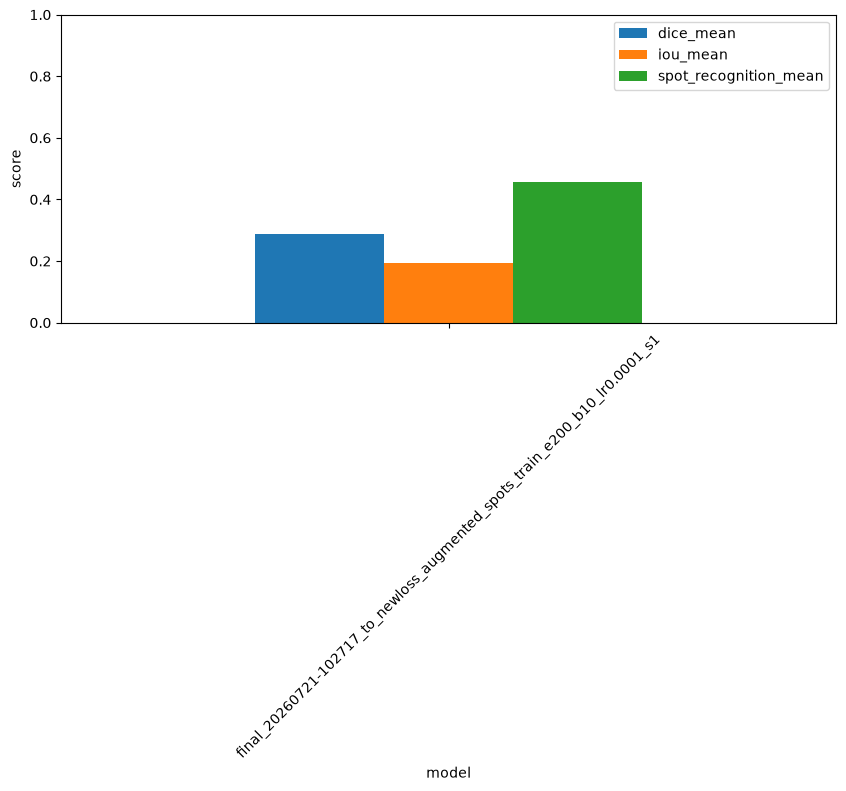

In [23]:
if not results.empty:
    summary = (
        results.groupby("model")
        .agg(
            n_samples=("sample_name", "count"),
            dice_mean=("dice_mean", "mean"),
            iou_mean=("iou_mean", "mean"),
            rmse_mean=("rmse_mean", "mean"),
            rmse_whole_mean=("rmse_whole_mean", "mean"),
            nrmse_mean=("nrmse_mean", "mean"),
            nrmse_whole_mean=("nrmse_whole_mean", "mean"),
            nrmse_positive_mean=("nrmse_positive_mean", "mean"),
            integrated_intensity_abs_relative_error_mean=("integrated_intensity_abs_relative_error_mean", "mean"),
            soft_intensity_dice_mean=("soft_intensity_dice_mean", "mean"),
            soft_intensity_dice_whole_mean=("soft_intensity_dice_whole_mean", "mean"),
            spot_recognition_mean=("spot_recognition_mean", "mean"),
            spot_recognition_p10=("spot_recognition_mean", lambda x: x.quantile(0.10)),
        )
        .sort_values("spot_recognition_mean", ascending=False)
    )
    if "timing_results" in globals() and not timing_results.empty:
        timing_cols = [
            "model",
            "total_eval_seconds",
            "seconds_per_sample",
            "seconds_per_spot",
            "samples_per_second",
            "spots_per_second",
        ]
        summary = summary.join(timing_results[timing_cols].set_index("model"), how="left")
    display(summary)

    axes = summary[["dice_mean", "iou_mean", "spot_recognition_mean"]].plot(kind="bar", figsize=(10, 4), rot=45)
    axes.set_ylim(0, 1)
    axes.set_ylabel("score")
    axes.figure.tight_layout()


## Runtime

Runtime is measured around the full evaluation loop for each model. On CUDA, the notebook synchronizes before and after inference/metric sections so the timings include actual GPU work instead of only queueing time.

In [ ]:
if "timing_results" in globals() and not timing_results.empty:
    display(timing_results.sort_values("seconds_per_spot"))
    ax = timing_results.sort_values("seconds_per_spot").plot(
        x="model",
        y=["seconds_per_sample", "seconds_per_spot"],
        kind="bar",
        figsize=(10, 4),
        rot=45,
    )
    ax.set_ylabel("seconds")
    ax.figure.tight_layout()

## Spot counter

Each sample contributes two target spots. The counter uses the combined Dice/RMSE recognition score and counts spots in `<50%`, `50-70%`, `70-90%`, and `>90%`.

In [ ]:
if not spot_results.empty:
    spot_results["recognition_bin"] = pd.Categorical(spot_results["recognition_bin"], categories=SPOT_BIN_ORDER, ordered=True)
    spot_counter = (
        spot_results.groupby(["model", "recognition_bin"], observed=False)
        .size()
        .unstack(fill_value=0)
        .reindex(columns=SPOT_BIN_ORDER, fill_value=0)
    )
    spot_counter["total_spots"] = spot_counter.sum(axis=1)
    for bin_name in SPOT_BIN_ORDER:
        spot_counter[f"{bin_name}_fraction"] = spot_counter[bin_name] / spot_counter["total_spots"].clip(lower=1)
    spot_counter.to_csv(OUTPUT_DIR / "spot_counter_5000.csv")
    display(spot_counter)

    axes = spot_counter[SPOT_BIN_ORDER].plot(kind="bar", stacked=True, figsize=(10, 4), rot=45)
    axes.set_ylabel("spots")
    axes.figure.tight_layout()

## Dataset-level metrics

Group by the source dataset/experiment, e.g. Al, Iron, IN718, Ti7Al. This is usually more interpretable than individual donor IDs for a thesis result table.


In [ ]:
def dataset_label(experiment):
    text = str(experiment)
    text = text.replace(".h5", "")
    text = text.replace("_logtif", "")
    if text in {"Al_segvol", "Al"}:
        return "Al"
    if text.startswith("Al_deformed_LoG"):
        return "Al_deformed_LoG"
    if text.startswith("Al_big_grains"):
        return "Al_big_grains"
    if text.startswith("Al_small_grains"):
        return "Al_small_grains"
    if text.startswith("Cu"):
        return "Cu"
    if text.startswith("IN718_twins"):
        return "IN718_twins"
    if text.startswith("Iron_deformed"):
        return "Iron_deformed"
    if text.startswith("Iron"):
        return "Iron"
    if text.startswith("Ti7Al"):
        return "Ti7Al"
    return text

if not results.empty and "experiment" in results.columns:
    results["dataset"] = results["experiment"].map(dataset_label)
    agg = {
        "n_samples": ("sample_name", "count"),
        "dice_mean": ("dice_mean", "mean"),
        "iou_mean": ("iou_mean", "mean"),
        "rmse_mean": ("rmse_mean", "mean"),
        "rmse_whole_mean": ("rmse_whole_mean", "mean"),
        "nrmse_mean": ("nrmse_mean", "mean"),
        "nrmse_whole_mean": ("nrmse_whole_mean", "mean"),
        "nrmse_positive_mean": ("nrmse_positive_mean", "mean"),
        "integrated_intensity_abs_relative_error_mean": ("integrated_intensity_abs_relative_error_mean", "mean"),
        "spot_recognition_mean": ("spot_recognition_mean", "mean"),
        "spot_recognition_p10": ("spot_recognition_mean", lambda x: x.quantile(0.10)),
    }
    if "soft_intensity_dice_mean" in results.columns:
        agg["soft_intensity_dice_mean"] = ("soft_intensity_dice_mean", "mean")
        agg["soft_intensity_dice_whole_mean"] = ("soft_intensity_dice_whole_mean", "mean")
    dataset_summary = results.groupby(["model", "dataset"]).agg(**agg).sort_values(["model", "dice_mean"], ascending=[True, False])
    dataset_summary.to_csv(OUTPUT_DIR / "dataset_separation_metrics_5000.csv")
    display(dataset_summary)
else:
    print("No experiment column found; cannot compute dataset-level metrics.")


## Which donors/samples are predicted well or badly?

A sample contains two donors, so the per-donor table explodes each sample into one row per donor key. This only works if donor metadata survived in the HDF5 file.

In [ ]:
def explode_donors(df):
    rows = []
    for row in df.to_dict("records"):
        donor_keys = row.get("donor_keys") or []
        for donor_key in donor_keys:
            new_row = row.copy()
            new_row["donor_key"] = donor_key
            rows.append(new_row)
    return pd.DataFrame(rows)


if not results.empty:
    donor_results = explode_donors(results)
    if donor_results.empty:
        print("No donor metadata found in this HDF5 file. Check sample attrs['donors'] or root provenance in the inspection report above.")
    else:
        donor_summary = (
            donor_results.groupby(["model", "donor_key"])
            .agg(
                n=("sample_name", "count"),
                dice_mean=("dice_mean", "mean"),
                iou_mean=("iou_mean", "mean"),
                rmse_mean=("rmse_mean", "mean"),
                spot_recognition_mean=("spot_recognition_mean", "mean"),
                spot_recognition_p10=("spot_recognition_mean", lambda x: x.quantile(0.10)),
            )
            .query("n >= 3")
            .sort_values(["model", "spot_recognition_mean"], ascending=[True, True])
        )
        donor_summary.to_csv(OUTPUT_DIR / "donor_separation_metrics_5000.csv")
        display(donor_summary.head(20))

        print("Best donors:")
        display(donor_summary.sort_values("spot_recognition_mean", ascending=False).head(20))

## Worst examples for visual inspection

In [ ]:
def plot_sample_prediction(model_path, sample_name):
    model = load_model(model_path)
    single = H5SubsetDataset(DATA_PATH, [sample_name])
    batch = collate_batch([single[0]])
    image = batch["image"].to(DEVICE, dtype=torch.float32)
    target_intensity = batch["target_intensity"].to(DEVICE, dtype=torch.float32)
    target_mask = batch["target_mask"].to(DEVICE, dtype=torch.bool)

    with torch.no_grad():
        pred = spot_intensity_prediction(model(image))
        if pred.shape != target_intensity.shape:
            pred = F.interpolate(pred, size=target_intensity.shape[2:], mode="bilinear", align_corners=False)
        pred, _ = align_prediction_channels(pred, target_intensity, target_mask)
        pred_mask = prediction_masks_from_intensity(pred)

    image_np = image[0, 0].cpu().numpy()
    target_np = target_intensity[0].cpu().numpy()
    target_mask_np = target_mask[0].cpu().numpy()
    pred_np = pred[0].cpu().numpy()
    pred_mask_np = pred_mask[0].cpu().numpy()

    fig, axes = plt.subplots(3, 4, figsize=(12, 8), constrained_layout=True)
    panels = [
        (image_np, "input", "gray"),
        (target_mask_np[0], "target mask 0", "gray"),
        (pred_mask_np[0], "pred mask 0", "gray"),
        (np.abs(pred_mask_np[0].astype(float) - target_mask_np[0].astype(float)), "mask error 0", "magma"),
        (target_np.sum(axis=0), "target intensity sum", "gray"),
        (target_np[0], "target intensity 0", "gray"),
        (pred_np[0], "pred intensity 0", "gray"),
        (np.abs(pred_np[0] - target_np[0]), "intensity error 0", "magma"),
        (pred_np.sum(axis=0), "pred intensity sum", "gray"),
        (target_mask_np[1], "target mask 1", "gray"),
        (pred_mask_np[1], "pred mask 1", "gray"),
        (np.abs(pred_mask_np[1].astype(float) - target_mask_np[1].astype(float)), "mask error 1", "magma"),
    ]
    for ax, (data, title, cmap) in zip(axes.flat, panels):
        ax.imshow(data, cmap=cmap, vmin=0, vmax=1)
        ax.set_title(title)
        ax.axis("off")
    fig.suptitle(f"{Path(model_path).name} | {sample_name}")
    plt.show()
    del model


if not results.empty:
    worst = results.sort_values("spot_recognition_mean").head(10)[[
        "model", "model_path", "sample_name", "dice_mean", "iou_mean", "rmse_mean", "spot_recognition_mean", "donor_keys"
    ]]
    display(worst)
    first = worst.iloc[0]
    plot_sample_prediction(Path(first["model_path"]), first["sample_name"])

## Notes on the spot-recognition bins

The binning intentionally uses a combined mask/intensity criterion. Dice alone answers whether the segmented spot overlaps the mask; RMSE catches cases where the spot outline is plausible but the predicted intensity is too weak or too strong. If you want a stricter counter, adjust `DICE_WEIGHT` and `RMSE_WEIGHT` or require both conditions independently, for example `dice > 0.9 and normalized_RMSE < 0.1` for the `>90%` bin.